In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("diabetes - diabetes.csv")

In [4]:
print(df)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

In [6]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [14]:
df.rename(columns={
        'Pregnancies' : 'preg',
        'Glucose' : 'glu',
        'BloodPressure' : 'BP',
        'SkinThickness' : 'SThick',
        'Insulin' : 'Ins',
        'DiabetesPedigreeFunction' : 'DPF',
        },inplace=True)

print(df.columns)

Index(['preg', 'glu', 'BP', 'SThick', 'Ins', 'BMI', 'DPF', 'Age', 'Outcome'], dtype='str')


<Axes: >

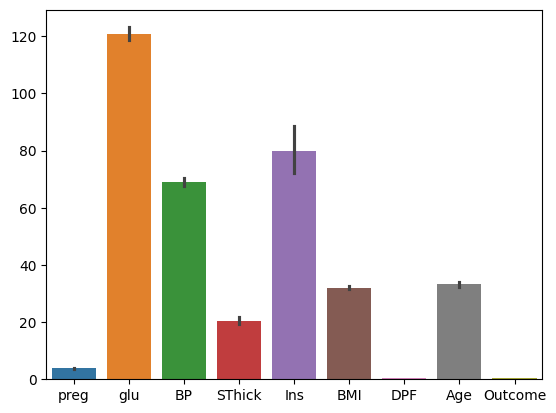

In [15]:
sns.barplot(df)

<Axes: xlabel='BP', ylabel='Ins'>

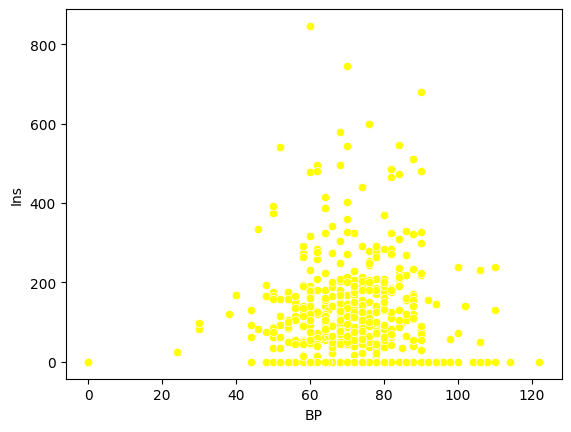

In [20]:
sns.scatterplot(df,x = 'BP', y = 'Ins' , color = 'yellow')

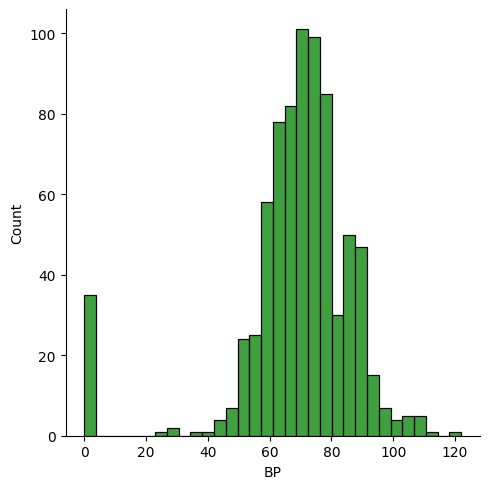

In [21]:
sns.displot(data=df, x='BP', color='green')

<Axes: xlabel='BP', ylabel='Outcome'>

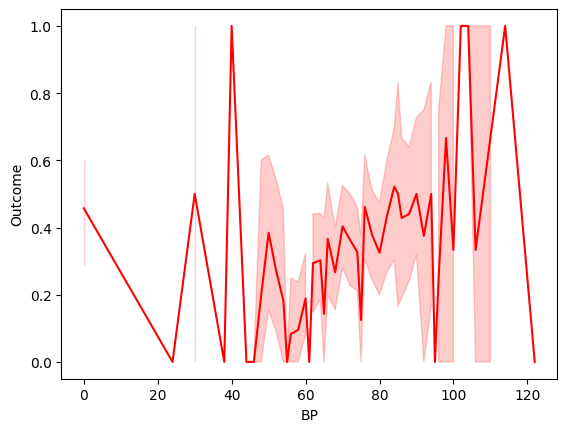

In [22]:
sns.lineplot(data=df, x='BP', y='Outcome', color='red')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification # for creating artificial data clasification 
from sklearn.linear_model import LogisticRegression # importing the model for classification 
from sklearn.metrics import accuracy_score,classification_report


In [ ]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
binary_model = LogisticRegression()
binary_model.fit(X_train, y_train)

y_pred = binary_model.predict(X_test)

print("=== Binary Classification Performance ===")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")

print("\nDetailed Metrics:")
print(classification_report(y_test, y_pred))

=== Binary Classification Performance ===
Accuracy Score: 0.7995

Detailed Metrics:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       254
           1       0.72      0.68      0.70       130

    accuracy                           0.80       384
   macro avg       0.78      0.77      0.77       384
weighted avg       0.80      0.80      0.80       384



C:\Users\Asus Tuf\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X, y, test_size=0.3, random_state=42
)

multiclass_model = RandomForestClassifier(
    n_estimators=100,
    random_state=40
)

multiclass_model.fit(X_train_m, y_train_m)

# 4. Generate predictions
y_pred_m = multiclass_model.predict(X_test_m)

# 5. Evaluate the model performance
print("=== Random Forest Classification Performance ===")
print(f"Accuracy Score: {accuracy_score(y_test_m, y_pred_m):.4f}")

print("\nDetailed Metrics:")
print(classification_report(y_test_m, y_pred_m))

=== Random Forest Classification Performance ===
Accuracy Score: 0.7812

Detailed Metrics:
              precision    recall  f1-score   support

           0       0.84      0.83      0.83       254
           1       0.67      0.68      0.68       130

    accuracy                           0.78       384
   macro avg       0.76      0.76      0.76       384
weighted avg       0.78      0.78      0.78       384

